# Actual J-lens / J-space readouts on pretrained Gemma 4

This notebook fits Anthropic's **actual Jacobian-lens implementation** to **pretrained Gemma 4 E2B**, not a randomly initialized language model. Four generic sentences fit one transport matrix at layer 8; six separate capital-city prompts evaluate readouts.

Use the dedicated CUDA environment with `.[pretrained,jlens,notebooks]` and prepare the pinned model cache as described in `docs/pretrained.md`. The notebook is cache-only. Restart the kernel before rerunning so an old model does not occupy GPU memory.

**Scope:** a small, illustrative pretrained-model experiment—not the paper's large-corpus fit or a claim to read literal thoughts. A source-country token ranking measures readable token identity, not next-token prediction or reasoning accuracy.

In [1]:
import os, time, json, resource, sys
os.environ.setdefault("USE_TF", "0")
os.environ["HF_HUB_OFFLINE"] = "1"
import torch, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import display, JSON
from autoexplain.pretrained import load_gemma4
from autoexplain.pretrained_jlens import fit_pretrained_jlens
torch.set_num_threads(2)
torch.manual_seed(7)
assert torch.cuda.is_available(), "This measured profile uses CUDA; no random fallback."
torch.cuda.reset_peak_memory_stats()
started = time.perf_counter()
bundle = load_gemma4(allow_download=False)
display(JSON(bundle.metadata, expanded=True))


/home/ptthang/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<IPython.core.display.JSON object>

## 1. Fit on a disjoint corpus

The estimator sums cotangents over valid current/future target positions and averages gradients over valid source positions, then averages prompts. It skips BOS and the final token. Per-layer token identity and shared-KV paths other than the intervened residual are otherwise held fixed.

The four fitting sentences contain none of the six evaluation country prompts. Only one layer and four prompts are fitted; convergence across corpora or larger budgets is **not established**.

In [2]:
lens, report = fit_pretrained_jlens(bundle)
print("Fitting corpus:")
for prompt in report["fit_prompts"]: print("-", prompt)
print("Layer:", report["layer"], "| prompts:", report["fit_prompt_count"],
      "| fitting seconds:", round(report["fit_seconds"], 3))
print("Transport Frobenius norm:", report["transport_frobenius_norm"])
# Optional: lens.save("my_gemma4_layer8_lens.pt") -- not committed with the repository.


Fitting corpus:
- A small bird landed on a branch near the window.
- The student opened a book and began reading quietly.
- Several people walked through the park after the rain.
- We placed the wooden box on the table beside the door.
Layer: 8 | prompts: 4 | fitting seconds: 18.341
Transport Frobenius norm: 48.55608367919922


## 2. Compare J-lens, plain logit lens, and a scrambled alignment control

The scrambled lens permutes the fitted matrix's input-coordinate columns. It preserves matrix norms and singular values while breaking coordinate alignment. This is one seeded negative control, not a distribution of independently fitted random lenses.

Rank uses **1 + the number of strictly larger scores**; ties share rank. The target for this diagnostic is the country token already present in the input. Keep that narrower claim separate from interpreting an abstract concept.

,prompt,country token,jacobian_lens,logit_lens,scrambled_lens
0,The capital of France is,France,1,141590,101958
1,The capital of Germany is,Germany,1,157630,171915
2,The capital of Italy is,Italy,1,101719,227661
3,The capital of Spain is,Spain,12,225802,246839
4,The capital of Japan is,Japan,1,216039,197569
5,The capital of China is,China,1,171617,174539


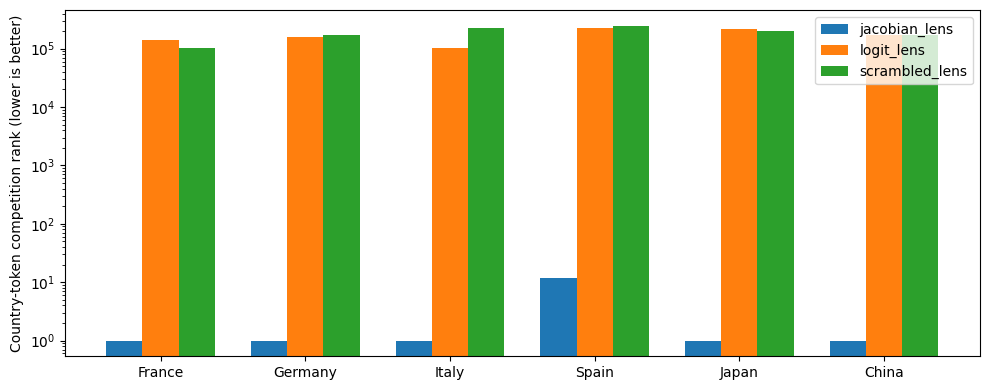

In [3]:
rank_rows = []
for row in report["readouts"]:
    rank_rows.append({"prompt": row["prompt"], "country token": row["country_token"],
                      **row["country_token_ranks"]})
display(pd.DataFrame(rank_rows))
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(rank_rows))
for offset, method in zip([-.25, 0, .25], ["jacobian_lens", "logit_lens", "scrambled_lens"]):
    ax.bar(x+offset, [r[method] for r in rank_rows], width=.25, label=method)
ax.set_yscale("log")
ax.set_xticks(x, [r["country token"].strip() for r in rank_rows])
ax.set_ylabel("Country-token competition rank (lower is better)")
ax.legend(); plt.tight_layout(); plt.show()


## 3. Read the actual vocabulary outputs

The country-position readout and final-prompt-position readout answer different questions. The latter is not guaranteed to rank the correct capital first; an intermediate representation can have readable associations without matching the model's final answer. All six cases and all three methods are retained below.

In [4]:
rows = []
for sample in report["readouts"]:
    for position, key in [("country", "country_readouts"), ("last", "last_readouts")]:
        for method, tokens in sample[key].items():
            rows.append({"prompt": sample["prompt"], "position": position, "method": method,
                         "top vocabulary strings": [t["text"] for t in tokens]})
with pd.option_context("display.max_rows", 40, "display.max_colwidth", 100):
    display(pd.DataFrame(rows))
print("Actual final-model top tokens:")
display(pd.DataFrame([{"prompt": r["prompt"],
                       "top tokens": [t["text"] for t in r["actual_next_token_top5"]]}
                      for r in report["readouts"]]))


,prompt,position,method,top vocabulary strings
0,The capital of France is,country,jacobian_lens,"[法国, France, францу, Strasbourg, France]"
1,The capital of France is,country,logit_lens,"[CharArray, Invitation, begeistert, $|\, 作った]"
2,The capital of France is,country,scrambled_lens,"[</i>, كرة, clear, claro, kay]"
3,The capital of France is,last,jacobian_lens,"[ város, şehir, столи, château, città]"
4,The capital of France is,last,logit_lens,"[긔, spiaggia, níku, dto, 趣味]"
5,The capital of France is,last,scrambled_lens,"[گذار, conde, </i>, ཀ, catalog]"
6,The capital of Germany is,country,jacobian_lens,"[Germany, Austria, Austria, Frankreich, Germany]"
7,The capital of Germany is,country,logit_lens,"[ reacting, contacting, fazendo, ulsions, ற்றில்]"
8,The capital of Germany is,country,scrambled_lens,"[quilla, khỏi, keen, ковка, getConfig]"
9,The capital of Germany is,last,jacobian_lens,"[ Avrupa, város, şehir, 유럽, столи]"


Actual final-model top tokens:


,prompt,top tokens
0,The capital of France is,"[ Paris, a, the, known, one]"
1,The capital of Germany is,"[ Berlin, a, the, , known]"
2,The capital of Italy is,"[ Rome, a, the, one, known]"
3,The capital of Spain is,"[ Madrid, a, the, one, known]"
4,The capital of Japan is,"[ Tokyo, a, known, , located]"
5,The capital of China is,"[ Beijing, a, known, the, in]"


## 4. Full results and compute footprint

A readable vocabulary list is not evidence that a model literally thinks in those words. This notebook does not identify a reasoning circuit, demonstrate steering, or validate a J-space theory. Those claims require additional interventions and controls.

The result below was computed in this kernel. The original model weights were not modified by lens fitting. The fit uses a dedicated model instance because the upstream adapter freezes parameters and switches it to evaluation mode.

In [5]:
display(JSON(report, expanded=False))
rss=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib=rss/(1024**2 if sys.platform=="darwin" else 1024)
print(json.dumps({
    "tutorial_compute_wall_seconds":round(time.perf_counter()-started,3),
    "kernel_lifetime_peak_rss_mib":round(rss_mib,2),
    "memory_scope":"kernel only, including CPU embedding table and imports",
    "gpu_peak_allocated_gib":round(torch.cuda.max_memory_allocated()/1024**3,3),
    "gpu_peak_reserved_gib":round(torch.cuda.max_memory_reserved()/1024**3,3)
}))


<IPython.core.display.JSON object>

{"tutorial_compute_wall_seconds": 24.07, "kernel_lifetime_peak_rss_mib": 6340.41, "memory_scope": "kernel only, including CPU embedding table and imports", "gpu_peak_allocated_gib": 4.601, "gpu_peak_reserved_gib": 4.645}
